In [6]:
#!/usr/bin/env python3
import random, numpy as np, pandas as pd, torch, gc
from pathlib import Path
from tqdm import tqdm
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# ── params ───────────────────────────────────────────
IMG_DIR = Path("dataset")
CSV_OUT = "submission_resnet.csv"
BATCH   = 64
DIM     = 2048
DEVICE  = "mps" if torch.backends.mps.is_available() else "cpu"
SEED    = 42
torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)
print("device =", DEVICE)

# ── dataset ─────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class ImgDS(Dataset):
    def __init__(self, root):
        self.paths = sorted([p for p in root.iterdir()
                             if p.suffix.lower() in {'.png','.jpg','.jpeg'}])
    def __len__(self):  return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return transform(img)

ds = ImgDS(IMG_DIR)
loader = DataLoader(ds, batch_size=BATCH, shuffle=False, num_workers=0)

# ── encoder (ResNet-50 + projection) ───────────────
class ResNetEmbed(torch.nn.Module):
    def __init__(self, dim=512):
        super().__init__()
        base = models.resnet50(weights="IMAGENET1K_V2")
        self.backbone = torch.nn.Sequential(*list(base.children())[:-2])
        self.pool = torch.nn.AdaptiveAvgPool2d(1)
        self.proj = torch.nn.Linear(2048, dim)
    def forward(self,x):
        h = self.backbone(x)
        h = self.pool(h).flatten(1)
        z = self.proj(h)
        return z

model = ResNetEmbed(DIM).to(DEVICE).eval()

# ── извлекаем эмбеддинги ───────────────────────────
vectors = torch.zeros((len(ds), DIM), dtype=torch.float32)
with torch.no_grad():
    idx = 0
    for x in tqdm(loader, desc="encode"):
        z = model(x.to(DEVICE))
        z = z / z.norm(dim=1, keepdim=True)
        vectors[idx:idx+z.size(0)] = z.cpu()
        idx += z.size(0)

all_z = vectors.numpy()
del vectors, z, x; gc.collect()

# ── similarity search (numpy, блоками) ─────────────
N, K, CHUNK = all_z.shape[0], 6, 4096
rank = np.empty((N, K), int)

for s in tqdm(range(0, N, CHUNK), desc="similarity"):
    e = min(s+CHUNK, N)
    sims = np.dot(all_z[s:e], all_z.T)          # cos-sim
    sims[np.arange(e-s), np.arange(s,e)] = -np.inf
    rank[s:e] = np.argpartition(-sims, K, axis=1)[:, :K]

# ── save csv ───────────────────────────────────────
records=[]
for i in range(N):
    neigh = [ds.paths[j].name for j in rank[i]]
    records.append({"filename": ds.paths[i].name,
                    "ranking": " ".join(neigh)})
pd.DataFrame(records).to_csv(CSV_OUT, index=False)
print("✓ saved", CSV_OUT)

device = mps


similarity: 100%|██████████| 3/3 [00:01<00:00,  2.59it/s]


✓ saved submission_resnet.csv


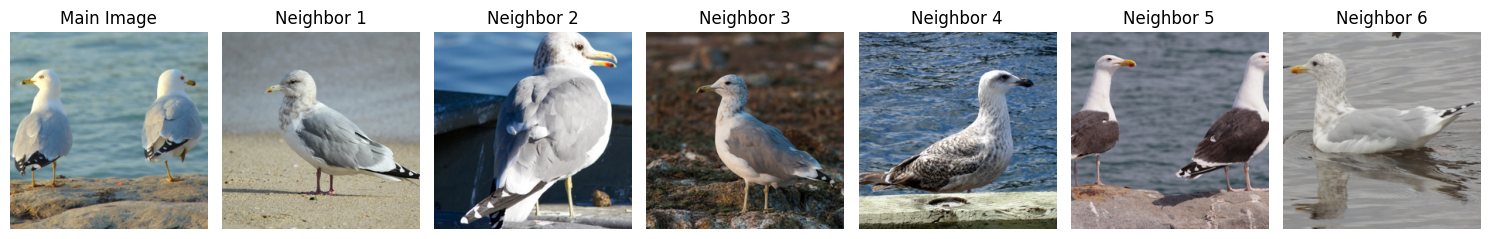

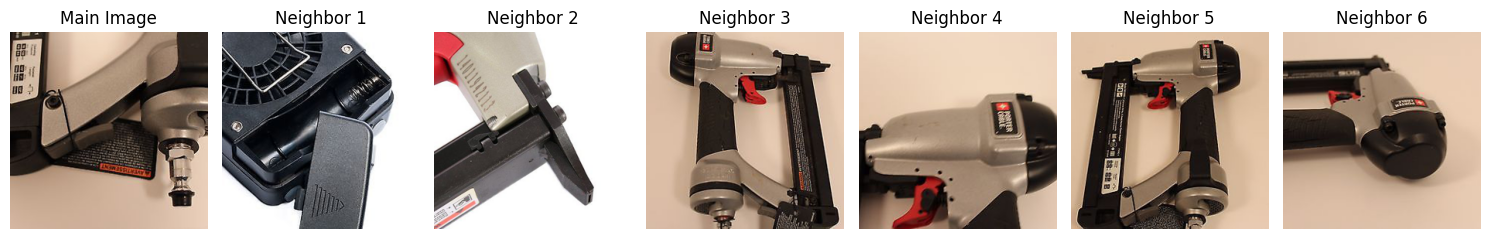

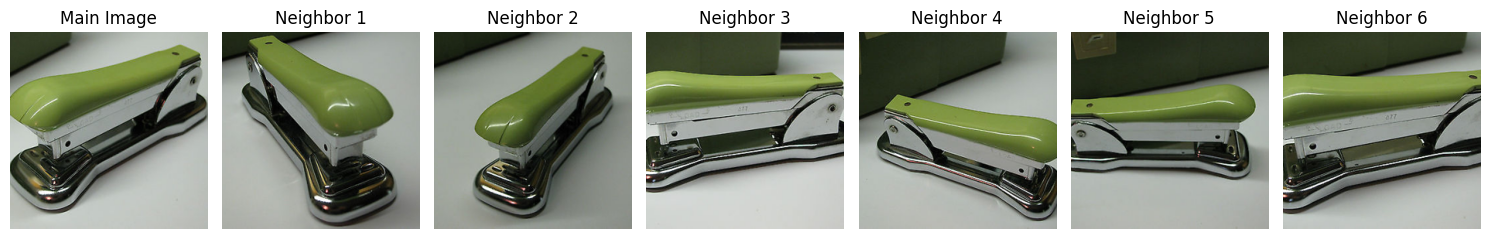

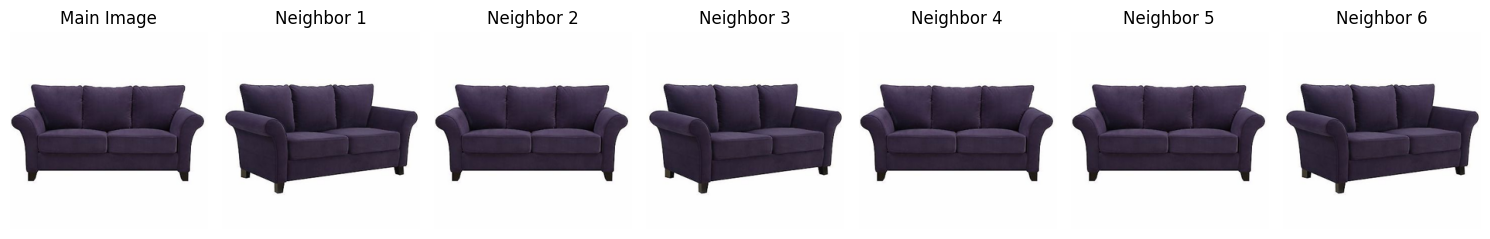

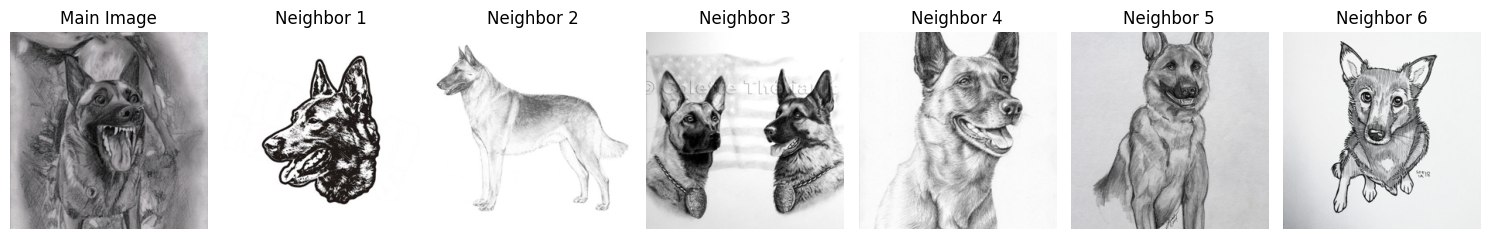

In [7]:
import matplotlib.pyplot as plt

# ── вывод картинок для 3 случайных изображений ───────
random_indices = random.sample(range(len(records)), 5)

for idx in random_indices:
    # Получаем имя файла и соседей
    filename = records[idx]["filename"]
    neighbors = records[idx]["ranking"].split()

    # Загружаем основное изображение
    main_img = Image.open(IMG_DIR / filename).convert("RGB")

    # Загружаем соседей
    neighbor_imgs = [Image.open(IMG_DIR / neigh).convert("RGB") for neigh in neighbors]

    # Создаем фигуру для отображения
    fig, axes = plt.subplots(1, len(neighbor_imgs) + 1, figsize=(15, 5))
    axes[0].imshow(main_img)
    axes[0].set_title("Main Image")
    axes[0].axis("off")

    for i, img in enumerate(neighbor_imgs):
        axes[i + 1].imshow(img)
        axes[i + 1].set_title(f"Neighbor {i + 1}")
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.show()